<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running trajectory: Mini-Batch SGD...
Running trajectory: SGD + Momentum...
Running trajectory: RMSProp...
Running trajectory: Adam...


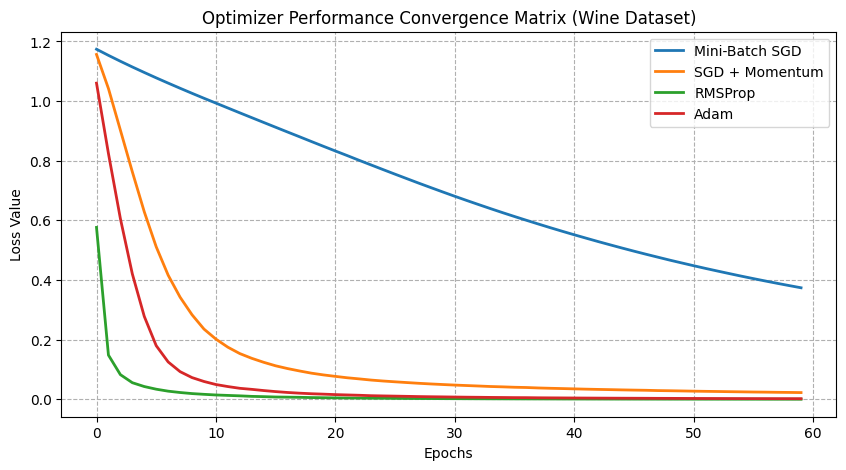

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load Wine Data
wine = load_wine()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)
X_train, _, y_train, _ = train_test_split(X_scaled, wine.target, test_size=0.1, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

# 2. Network Architecture
class WineOptimizerNet(nn.Module):
    def __init__(self):
        super(WineOptimizerNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
    def forward(self, x): return self.network(x)

# 3. Experiment Parameters
epochs = 60
batch_size = 16
learning_rate = 0.005
criterion = nn.CrossEntropyLoss()

optimizers_dict = {
    'Mini-Batch SGD': lambda model: optim.SGD(model.parameters(), lr=learning_rate),
    'SGD + Momentum': lambda model: optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9),
    'RMSProp': lambda model: optim.RMSprop(model.parameters(), lr=learning_rate, alpha=0.99),
    'Adam': lambda model: optim.Adam(model.parameters(), lr=learning_rate)
}

history = {name: [] for name in optimizers_dict}

# 4. Loop Through Optimizers
for name, opt_init in optimizers_dict.items():
    print(f"Running trajectory: {name}...")
    torch.manual_seed(42)  # Ensure identical weight initialization
    model = WineOptimizerNet()
    optimizer = opt_init(model)

    loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        epoch_loss = 0.0
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * bx.size(0)
        history[name].append(epoch_loss / len(loader.dataset))

# 5. Comparative Visual Analysis
plt.figure(figsize=(10, 5))
for name, losses in history.items():
    plt.plot(losses, label=name, lw=2)
plt.title('Optimizer Performance Convergence Matrix (Wine Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()